In [21]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

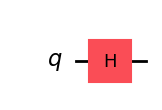

In [2]:

# Create a circuit with one qubit
circuit = QuantumCircuit(1)

# Add a Hadamard (H) gate on qubit 0, to create a superposition
circuit.h(0)

# Draw the circuit diagram. Delete "mpl" to get a text diagram.
circuit.draw("mpl")

In [3]:
# Now simulate the circuit by calculating the effect on state vectors.
# Set the initial state of the simulator to |0>
# The state vector has two coefficients, both 0
state = Statevector.from_int(0, 2)

# Apply the circuit to the state
state = state.evolve(circuit)

# Display using latex. This requires the pylatexenc module.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

In [4]:
# A different way of dislaying the state, again using latex
from qiskit.visualization import array_to_latex

array_to_latex(state)

<IPython.core.display.Latex object>

In [5]:
# The whole circuit is a unitary operator, which we can display.

U = Operator(circuit)
array_to_latex(U)

<IPython.core.display.Latex object>

In [6]:
# Or less beautifully:
U.data
# The format is a little bit odd. 0.j means the imaginary part is 0
# 0 is being displayed with a decimal point but no trailing 0
# j is used for the square root of -1, instead of i

array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

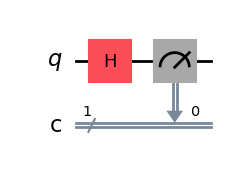

In [7]:
# Now reconstruct the circuit and add a measurement
# The second parameter of QuantumCircuit is the number of classical bits
circuit = QuantumCircuit(1,1)
circuit.h(0)

# The first list is the qubits to measure,
# the second list is the classical bits where the results go
circuit.measure([0],[0])
circuit.draw("mpl")

In [8]:
# We will need to transpile the circuit into QASM instructions for the back end

# Use BasicSimulator
backend = BasicSimulator()

# Compile / transpile
qc_compiled = transpile(circuit, backend)

# Run the circuit on the simulator.
# We've set the number of repeats of the circuit
# to be 1024, which is the default.
# The qubits start in state |0>
job_sim = backend.run(qc_compiled, shots=1024)

# Grab the results from the job (this doesn't produce any output).
result_sim = job_sim.result()

In [9]:
# The simplest way to see the results of the simulation
counts = result_sim.get_counts(qc_compiled)
print(counts)

# The results are not exactly half 0 and half 1, but should be close.
# There will be different results each time the previous cell is run.

{'0': 517, '1': 507}


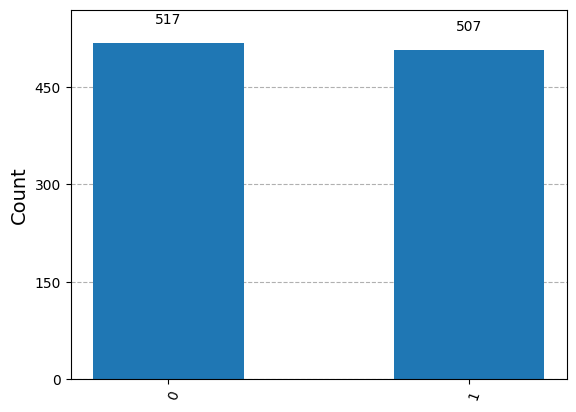

In [10]:
# We can also produce a graph

plot_histogram(counts)

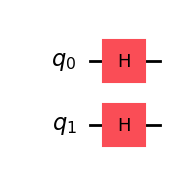

In [11]:
# Now let's move on to two qubits.
# Apply H to both qubits and see what we get.

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.h(1)

circuit.draw("mpl")

In [12]:
state = Statevector.from_int(0, 4) # 4 is the number of basis states on 2 qubits
state = state.evolve(circuit)
state.draw("latex")

<IPython.core.display.Latex object>

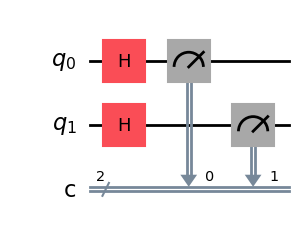

In [13]:
# Now measurement. This time we construct the measurement part
# of the circuit separately and then combine it with the first circuit.

# A new circuit with 2 qubits and 2 classical bits
meas = QuantumCircuit(2, 2)

# Map the quantum measurement to the classical bits
meas.measure(range(2), range(2))

# The Qiskit circuit object supports composition.
# Here the meas has to be first and front=True (putting it before)
# as compose must put a smaller circuit into a larger one.
qc = meas.compose(circuit, range(2), front=True)

qc.draw("mpl")

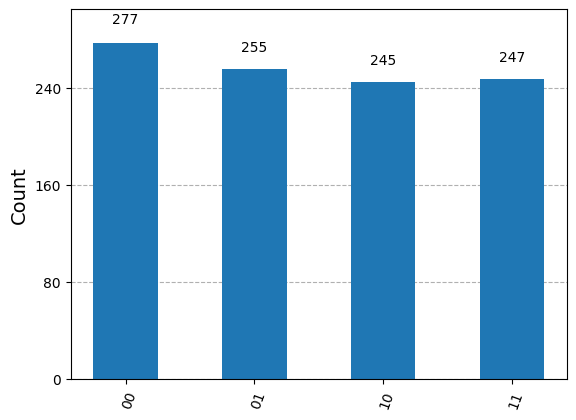

In [14]:
# Simulate again, using the same back end
qc_compiled = transpile(qc, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

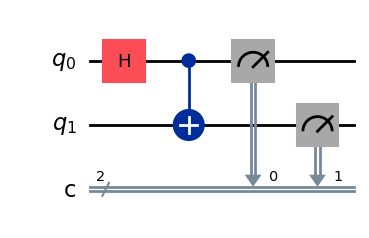

In [15]:
# Now for some entanglement.
# Construct a Bell state and measure both qubits to see that
# both measurements give the same result.

circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit.measure(range(2),range(2))
circuit.draw("mpl")

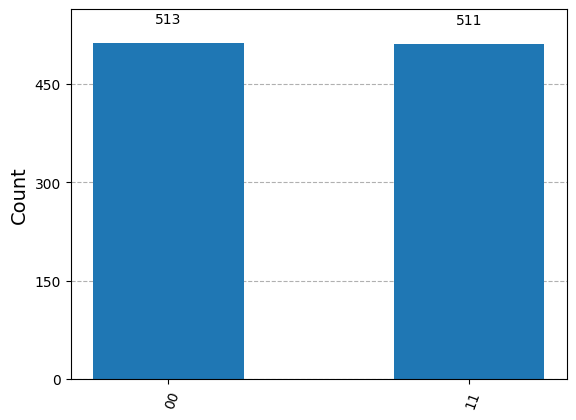

In [16]:
qc_compiled = transpile(circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

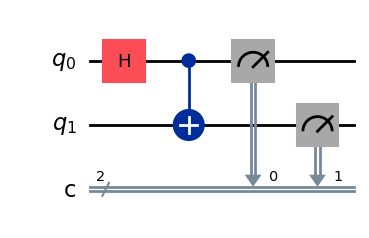

In [19]:
# EXERCISE

# Make a copy here of the circuit that creates the Bell state 1/sqrt(2) ( |00> + |11> ).

# Modify it to create the other Bell states: 1/sqrt(2) ( |00> - |11> ), 1/sqrt(2) ( |01> + |10> ), 1/sqrt(2) ( |01> - |10> ).

# You will need to use X and Z gates. Check that your circuit is correct by displaying the state vector in each case.

# For each of the Bell states, repeat the simulation with measurements and check that the results are as expected.

# bell1 = original circuit
bell1 = QuantumCircuit(2, 2)  # 2 qubits, 2 classical bits

bell1.h(0) # apply H to qubit 0 to create superposition

bell1.cx(0, 1) # apply CNOT (qubit 0 = control, qubit 1 = target) to create entanglement

bell1.measure(range(2), range(2))

bell1.draw("mpl")

In [28]:
# bell state 1 (original bell state)
bell1 = QuantumCircuit(2) # without classicial bits (only qubits)
bell1.h(0)
bell1.cx(0, 1)

state = Statevector.from_int(0, 4) # 2 qubits = 2^2 = 4 states
state = state.evolve(bell1)
state.draw("latex")

<IPython.core.display.Latex object>

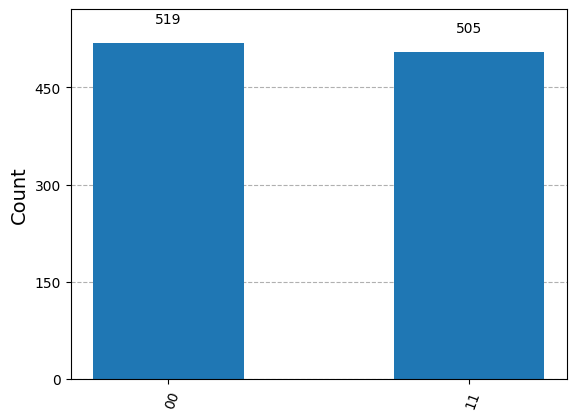

In [29]:
# bell state 1 with qubits and classical bits

bell1 = QuantumCircuit(2, 2)
bell1.h(0)
bell1.cx(0, 1) # apply CNOT
bell1.measure(range(2), range(2))
qc.compiled = transpile(bell1, backend)
job_sim = backend.run(qc_compiled, shots = 1024) # 1024 = no. of experiment repeats
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

# From histogram: shows that both 00 and 11 appears abt 50% of the time
# , proving the qubits are entangled. If one qubit is 0, the other is
# also 0. (Same for if qubit is 1)

In [30]:
# bell state 2

bell2 = QuantumCircuit(2)
bell2.h(0)
bell2.cx(0, 1)
bell2.z(0) # apply Z gate (0 or 1 both can be used)
state = Statevector.from_int(0, 4)
state = state.evolve(bell2)
state.draw("latex")


<IPython.core.display.Latex object>

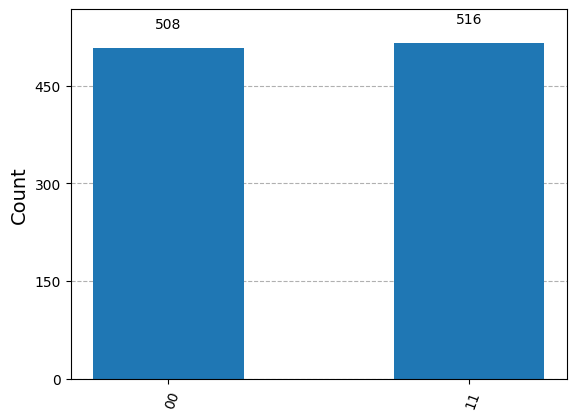

In [37]:
# bell state 2 with qubits and classical bits

bell2 = QuantumCircuit(2, 2)
bell2.h(0)
bell2.cx(0, 1) # apply CNOT
bell2.z(0)
bell2.measure(range(2), range(2))
qc.compiled = transpile(bell2, backend)
job_sim = backend.run(qc_compiled, shots = 1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

# From histogram: shows that both 00 and 11 appears even closer to abt
# 50% of the time, proving the qubits are entangled. If one qubit is 0
# , the other is also 0. (Same for if qubit is 1)

In [47]:
# bell state 3

bell3 = QuantumCircuit(2)
bell3.h(0)
bell3.cx(0, 1)
bell3.x(1) # apply Z gate (0 or 1 both can be used)
state = Statevector.from_int(0, 4)
state = state.evolve(bell3)
state.draw("latex")


<IPython.core.display.Latex object>

{'01': 539, '10': 485}


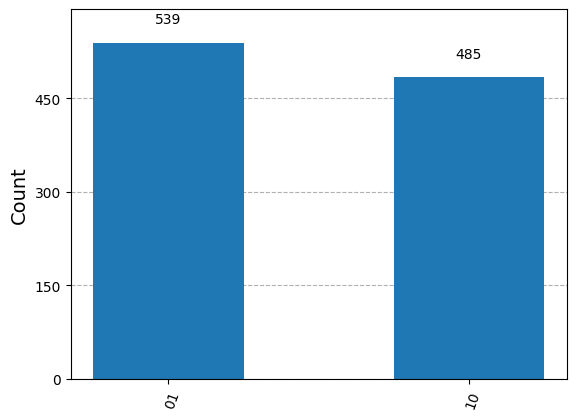

In [51]:
# Bell state 3 with qubits and classical bits

bell3 = QuantumCircuit(2, 2)
bell3.h(0)
bell3.cx(0, 1)
bell3.x(1)
bell3.measure(range(2), range(2))
qc_compiled = transpile(bell3, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
print(counts)
plot_histogram(counts)

# From Histogram: shows that the qubits are opposite. If first qubit
# is 0, second is 1 and vice versa for 1. However, the qubits are
# still entabled

In [54]:
# bell state 4

bell4 = QuantumCircuit(2)
bell4.h(0)
bell4.cx(0, 1)
bell4.x(1) # apply Z gate (0 or 1 both can be used)
bell4.z(1)
state = Statevector.from_int(0, 4)
state = state.evolve(bell4)
state.draw("latex")


<IPython.core.display.Latex object>

{'10': 508, '01': 516}


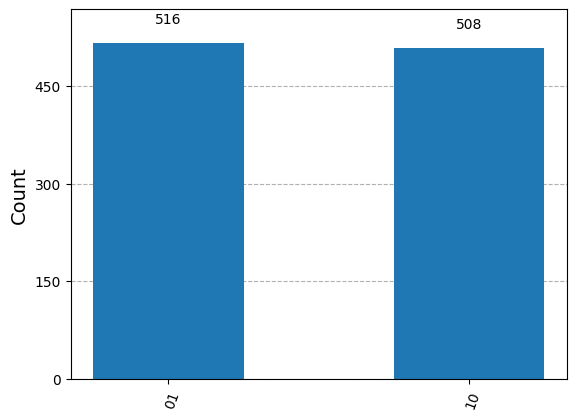

In [57]:
# Bell state 4 with qubits and classical bits

bell4 = QuantumCircuit(2, 2)
bell4.h(0)
bell4.cx(0, 1)
bell4.x(1)
bell4.z(1)
bell4.measure(range(2), range(2))
qc_compiled = transpile(bell4, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
print(counts)
plot_histogram(counts)

# From Histogram: shows that the qubits are opposite similar to
# bell3. The minus sign only changes the phase. However, the
# measurement probabilities remain the same.

In [18]:
# EXERCISE

# The GHZ state on any number of qubits has the form  1/sqrt(2) ( |00...0> + |11...1> )

# The Bell state 1/sqrt(2) ( |00> + |11> ) is the case for two qubits.

# Write code to construct a circuit that produces a GHZ state for any given number of qubits.

# Try simulating the circuit, with measurements. How many qubits can the simulator handle in a reasonable time?

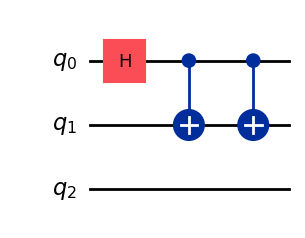

In [59]:
def create_ghz_circuit(n):
  circuit = QuantumCircuit(n)
  circuit.h(0) # put first qubit into superposition

  # entangle all qubits
  for i in range(1, n):
    circuit.cx(0, 1)
  return circuit

# create 3 qubit GHZ circuit
ghz3 = create_ghz_circuit(3)

# draw circuit diagram
ghz3.draw("mpl")

In [60]:
# create all quantum states of 3-bit qubit system
state = Statevector.from_int(0, 2 ** 3)

# apply ghz circuit
state = state.evolve(ghz3)

#display ghz state result
state.draw("latex")

<IPython.core.display.Latex object>

{'000': 500, '111': 524}


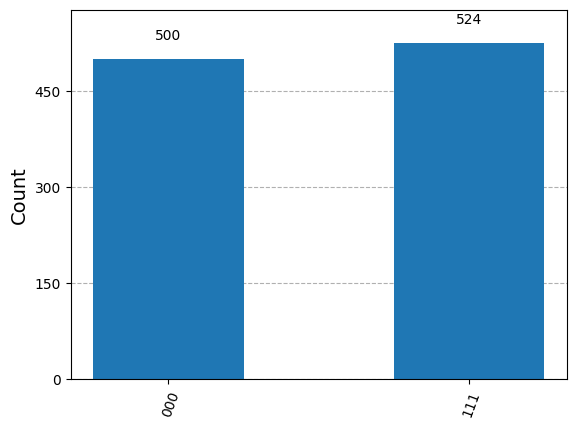

{'1111': 537, '0000': 487}


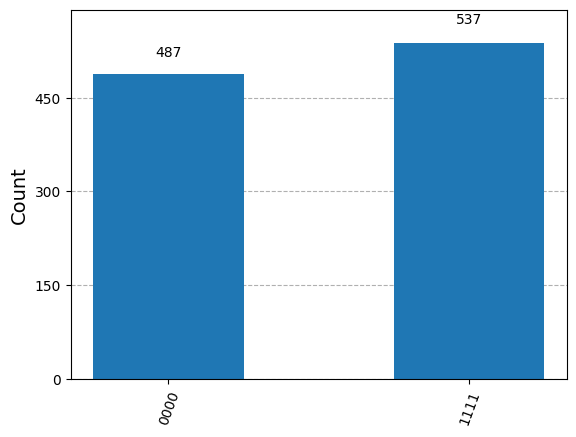

{'00000': 504, '11111': 520}


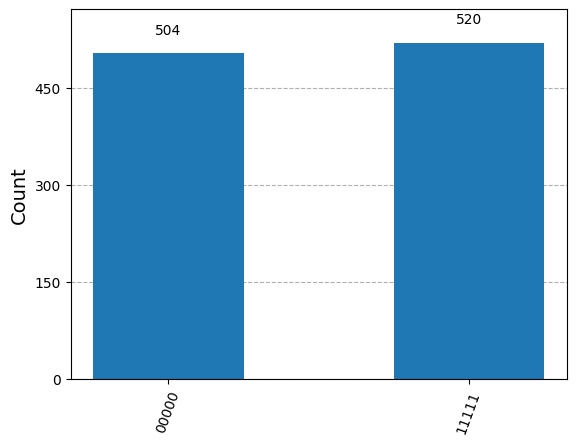

In [68]:
def simulate_ghz(n, shots = 1024):

  # create circuit with n qubits and n classical bits
  circuit = QuantumCircuit(n, n)

  circuit.h(0) # put qubit 0 into superposition

  # entable all qubits
  for i in range(1, n):
    circuit.cx(0, i) # apply CNOT

  circuit.measure(range(n), range(n))
  qc_compiled = transpile(circuit, backend)
  job_sim = backend.run(qc_compiled, shots = shots)
  result_sim = job_sim.result()
  counts = result_sim.get_counts(qc_compiled)
  print(counts)
  display(plot_histogram(counts))

  return circuit

simulate_ghz(3)

simulate_ghz(4)

simulate_ghz(5)